## Sample exclusion criteria
- This is sample exclusion criteria before preprocessing.
- (i) Missing age information
- (ii) dual disease phenotyping (PSC+UC)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
manu = pd.read_csv("data/1_preprocessing/1_manifest.tsv", sep=',')
meta = pd.read_csv("data/metadata.tsv", sep='\t')


In [3]:
meta_1 = meta.dropna(subset=["Months"])
meta_2 = meta_1[meta_1["Host_disease"] != "Primary sclerosing cholangitis and ulcerative colitis"]

In [4]:
meta_2["#SampleID"].count()

np.int64(146)

In [5]:
manu = manu[
    manu["sample-id"].str.replace(r"_[12]$", "", regex=True).isin(meta_2["#SampleID"])
]

manu["absolute-filepath"] = manu["absolute-filepath"].str.replace(
    "/data/raw/",
    "/data/raw/italy/",
    regex=False
)

In [ ]:
manu

In [7]:
meta_2

,#SampleID,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Center Name,Collection_Date,ReleaseDate,host_sex,geo_loc_name,Host_disease,Months,location_disease,BMI
0,SRR23478195,AMPLICON,501,49577775,PRJNA280490,SAMN33285910,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,female,Italy,Control,18.0,Control(IT),NaN
1,SRR23478196,AMPLICON,500,55244077,PRJNA280490,SAMN33285909,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,male,Italy,Control,18.0,Control(IT),NaN
2,SRR23478197,AMPLICON,500,36116963,PRJNA280490,SAMN33285908,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,female,Italy,Control,18.0,Control(IT),NaN
3,SRR23478198,AMPLICON,501,10054017,PRJNA280490,SAMN33285907,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,male,Italy,Control,30.0,Control(IT),NaN
4,SRR23478199,AMPLICON,500,33641193,PRJNA280490,SAMN33285906,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,male,Italy,Control,30.0,Control(IT),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,SRR23492553,AMPLICON,501,30047229,PRJNA935155,SAMN33299191,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2016,2023-10-24T00:00:00Z,NaN,Italy,ulcerative colitis,186.0,PIBD(IT),20.80
172,SRR23492554,AMPLICON,500,55389732,PRJNA935155,SAMN33299190,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2016,2023-10-24T00:00:00Z,NaN,Italy,ulcerative colitis,66.0,PIBD(IT),13.60
173,SRR23492555,AMPLICON,500,32161012,PRJNA935155,SAMN33299189,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2014,2023-10-24T00:00:00Z,NaN,Italy,ulcerative colitis,150.0,PIBD(IT),19.68
174,SRR23492556,AMPLICON,500,62317445,PRJNA935155,SAMN33299188,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2016,2023-10-24T00:00:00Z,NaN,Italy,ulcerative colitis,42.0,PIBD(IT),12.00


In [12]:
meta_2.head(2)

,#SampleID,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Center Name,Collection_Date,ReleaseDate,host_sex,geo_loc_name,Host_disease,Months,location_disease,BMI
0,SRR23478195,AMPLICON,501,49577775,PRJNA280490,SAMN33285910,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,female,Italy,Control,18.0,Control(IT),NaN
1,SRR23478196,AMPLICON,500,55244077,PRJNA280490,SAMN33285909,"BAMBINO GESU CHILDREN S HOSPITAL, IRCCS, ROME,...",2013,2024-03-01T00:00:00Z,male,Italy,Control,18.0,Control(IT),NaN


In [15]:
# BIOPROJECT host__disease value counts
disease_counts = (
    meta_2
    .groupby(["BioProject", "Host_disease"])
    .size()
    .reset_index(name="count")
)

print(disease_counts)

     BioProject        Host_disease  count
0  PRJNA1136812     crohn's disease     13
1  PRJNA1136812  ulcerative colitis     11
2   PRJNA280490             Control     95
3   PRJNA935155  ulcerative colitis     27


In [66]:
meta_2.to_csv("data/pre_metadata.tsv", sep='\t', index=False)

In [ ]:
manu.to_csv("data/1_preprocessing/pre_manifest.tsv", sep=',', index=False)

Text(0, 0.5, 'Count')

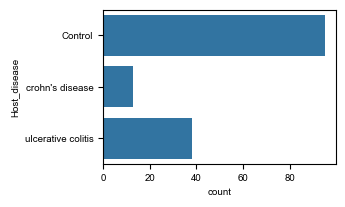

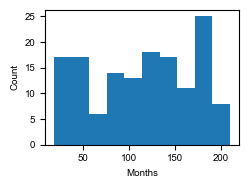

In [95]:
plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42


fig = plt.figure(figsize=(3,2))
ax = fig.add_subplot(111)

sns.countplot(meta_2["Host_disease"])

fig = plt.figure(figsize=(2.5,1.75))
ax = fig.add_subplot(111)
ax.hist(meta_2["Months"])
ax.set_xlabel("Months")
ax.set_ylabel("Count")
